# 실험② — 코드 · OCR · VLM 역할 분담

**이 노트북이 답할 질문**

> 문서 이미지에서 값을 뽑을 때, **무엇을 누구에게 맡겨야** VLM 의 날조를 막으면서 가장 많이 자동처리하는가?

설계: `docs/code_design.md` 의 `2026-10-03 — 2차 설계` · 근거: `docs/research.md` 의 `2026-10-03` 절

---

# 1. 합성기 — 정답을 먼저 정하고 문서를 그린다

직접 그리므로 **모든 필드의 값과 위치를 처음부터 안다.** 이 정답은 맨 뒤 **채점 절에서만** 쓴다.

In [1]:
from dataclasses import dataclass
from typing import Literal

@dataclass(frozen=True)
class FieldTruth:
    """정답 한 칸. frozen — 실험 도중 정답이 바뀌면 안 된다"""
    name: str                          # "total"
    value: str                         # 찍은 문자열 그대로 "1,234,000" — 숫자 변환은 채점에서
    kind: Literal["num", "text"]       # num → 산수·형식·OCR 대조 / text → OCR 대조만
    bbox: tuple[int, int, int, int]    # x1, y1, x2, y2 (픽셀) — 가리기 · 위치 채점용

In [2]:
from pathlib import Path
import urllib.request
from PIL import ImageFont

# 나눔고딕 — OFL(무료·재배포 가능). 시스템 폰트(AppleSDGothicNeo)는 애플 라이선스라 공개 이미지에 애매하다
FONT_DIR = Path("data/fonts"); FONT_DIR.mkdir(parents=True, exist_ok=True)   # data/ 는 git 제외
FONT_URL = "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
FONT_PATH = FONT_DIR / "NanumGothic-Regular.ttf"
if not FONT_PATH.exists():
    urllib.request.urlretrieve(FONT_URL, FONT_PATH)

def font(size: int) -> ImageFont.FreeTypeFont:
    """크기별 폰트. 각주처럼 작은 글씨는 VLM 이 놓치기 쉬운 자리라 일부러 만든다"""
    return ImageFont.truetype(str(FONT_PATH), size)

In [3]:
import random

# 사업자등록번호 — 끝자리가 앞 9자리의 체크섬이다. 그럴듯하게 바꿔 쓴 번호를 정답 없이 잡을 수 있다
BRN_W = [1, 3, 7, 1, 3, 7, 1, 3, 5]   # 국세청 가중치

def brn_check_digit(d9: list[int]) -> int:
    s = sum(d * w for d, w in zip(d9, BRN_W)) + (d9[8] * 5) // 10
    return (10 - s % 10) % 10

def fake_brn(rng: random.Random) -> str:
    """앞 3자리(세무서 코드)를 000 으로 — 실존 코드는 101 부터라 실제 사업자와 겹치지 않는다"""
    d9 = [0, 0, 0] + [rng.randint(0, 9) for _ in range(6)]
    d = d9 + [brn_check_digit(d9)]
    s = "".join(map(str, d))
    return f"{s[:3]}-{s[3:5]}-{s[5:]}"

In [4]:
from datetime import date, timedelta

# 누가 봐도 지어낸 이름만 쓴다 — 공개 저장소라 실존 회사·인물과 겹치면 안 된다
# (주) 앞·뒤 / 주식회사 앞·뒤를 섞는다 — VLM 이 표기를 바꿔 쓰는지 보는 재료
COMPANIES = ["테스트확인 주식회사", "(주)샘플상사", "가상솔루션(주)", "예시테크 주식회사", "(주)모의물산"]
ITEMS = [  # (품목명, 단위, 단가 최소, 최대, 수량 최대) — 값이 현실적이어야 "그럴듯한 오답" 실험이 의미 있다
    ("A4 복사용지 80g", "박스", 18000, 32000, 30),
    ("레이저 토너 카트리지", "개", 45000, 120000, 20),
    ("사무용 의자", "개", 89000, 350000, 15),
    ("유지보수 용역", "식", 500000, 3000000, 1),     # 용역은 1식
    ("네트워크 스위치 24포트", "대", 150000, 900000, 5),
    ("소프트웨어 라이선스(1년)", "카피", 120000, 800000, 10),
]
MANAGERS = ["홍길동", "김아무개", "이아무개", "박아무개", "최아무개"]

def quote_values(rng: random.Random) -> dict:
    """견적서 값만 만든다 (그리기는 다음 단계). 산수는 정답에서 반드시 성립한다"""
    items = []
    for name, unit_name, lo, hi, qmax in rng.sample(ITEMS, rng.randint(2, 5)):
        unit = rng.randrange(lo, hi, 100)          # 실제 단가처럼 100원 단위
        qty = rng.randint(1, qmax)                # 어색한 수량은 VLM 이 "고쳐 쓸" 수 있다
        items.append({"name": name, "unit_name": unit_name, "unit_price": unit, "qty": qty, "amount": unit * qty})
    supply = sum(i["amount"] for i in items)
    vat = supply // 10                              # 원 미만 버림 — 실물은 반올림도 있어 검산은 ±1원 허용
    supplier, client = rng.sample(COMPANIES, 2)
    return {
        "doc_no": f"Q-2026-{rng.randint(1, 999):04d}",
        "date": (date(2026, 1, 1) + timedelta(days=rng.randint(0, 270))).isoformat(),
        "supplier": supplier, "supplier_brn": fake_brn(rng),
        "client": client, "client_brn": fake_brn(rng),
        "manager": rng.choice(MANAGERS),
        "items": items, "supply": supply, "vat": vat, "total": supply + vat,
    }

quote_values(random.Random(0))

{'doc_no': 'Q-2026-0634',
 'date': '2026-05-09',
 'supplier': '(주)샘플상사',
 'supplier_brn': '000-89-24119',
 'client': '테스트확인 주식회사',
 'client_brn': '000-57-81569',
 'manager': '이아무개',
 'items': [{'name': '유지보수 용역',
   'unit_name': '식',
   'unit_price': 1826800,
   'qty': 1,
   'amount': 1826800},
  {'name': 'A4 복사용지 80g',
   'unit_name': '박스',
   'unit_price': 30200,
   'qty': 12,
   'amount': 362400},
  {'name': '사무용 의자',
   'unit_name': '개',
   'unit_price': 327900,
   'qty': 15,
   'amount': 4918500},
  {'name': '소프트웨어 라이선스(1년)',
   'unit_name': '카피',
   'unit_price': 298900,
   'qty': 9,
   'amount': 2690100},
  {'name': '레이저 토너 카트리지',
   'unit_name': '개',
   'unit_price': 59200,
   'qty': 10,
   'amount': 592000}],
 'supply': 10389800,
 'vat': 1038980,
 'total': 11428780}

In [5]:
from PIL import Image, ImageDraw

def put(draw: ImageDraw.ImageDraw, truths: list, xy, text: str, size: int,
        name: str | None = None, kind: str = "text", anchor: str = "la"):
    """글자를 그리고, name 이 있으면 그린 위치 그대로 정답에 기록한다.
       라벨("합계")은 name 없이 그리기만 — 채점 대상은 값이다. 금액 열은 anchor="ra"(오른쪽 정렬)"""
    f = font(size)
    draw.text(xy, text, font=f, fill="black", anchor=anchor)
    if name:
        truths.append(FieldTruth(name, text, kind, tuple(draw.textbbox(xy, text, font=f, anchor=anchor))))

# 확인 — 라벨은 기록되지 않고 값만 남는다
_img = Image.new("RGB", (400, 60), "white"); _d = ImageDraw.Draw(_img); _t = []
put(_d, _t, (10, 20), "합계", 20)
put(_d, _t, (390, 20), "71,901,390", 20, name="total", kind="num", anchor="ra")
_t

[FieldTruth(name='total', value='71,901,390', kind='num', bbox=(282, 23, 390, 41))]

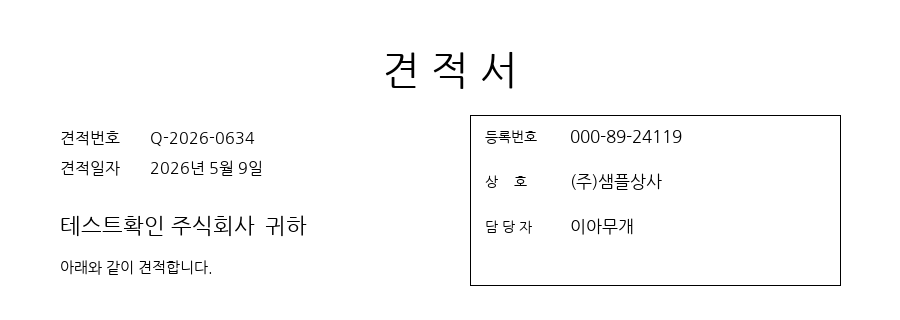

In [6]:
W, H = 900, 1273   # A4 비율. 이 크기의 이미지 토큰은 미측정 — 1일차 첫 호출에서 잰다

def draw_quote_header(d, t, v):
    """상단 — 제목 · 번호 · 날짜 · 공급받는자 · 공급자 박스"""
    put(d, t, (W // 2, 50), "견 적 서", 40, anchor="ma")
    y, m, dd = map(int, v["date"].split("-"))
    put(d, t, (60, 130), "견적번호", 16);  put(d, t, (150, 130), v["doc_no"], 16, name="doc_no", kind="num")
    # 날짜는 한국식으로 찍는다 — VLM 이 ISO 로 바꿔 쓰는지가 V1("보이는 그대로") 관찰 포인트
    put(d, t, (60, 160), "견적일자", 16);  put(d, t, (150, 160), f"{y}년 {m}월 {dd}일", 16, name="date", kind="num")
    put(d, t, (60, 215), v["client"], 22, name="client")
    put(d, t, (60 + d.textlength(v["client"], font=font(22)) + 10, 215), "귀하", 22)
    put(d, t, (60, 260), "아래와 같이 견적합니다.", 15)
    # 공급자 박스 — 라벨·값이 붙어 있어 공급자/공급받는자를 바꿔 읽는 실패가 생길 수 있는 자리
    d.rectangle((470, 115, 840, 285), outline="black")
    put(d, t, (485, 130), "등록번호", 14);  put(d, t, (570, 128), v["supplier_brn"], 17, name="supplier_brn", kind="num")
    put(d, t, (485, 175), "상    호", 14);  put(d, t, (570, 173), v["supplier"], 17, name="supplier")
    put(d, t, (485, 220), "담 당 자", 14);  put(d, t, (570, 218), v["manager"], 17, name="manager")

# 미리보기 — 상단만
_v = quote_values(random.Random(0))
_img = Image.new("RGB", (W, H), "white"); _t = []
draw_quote_header(ImageDraw.Draw(_img), _t, _v)
_img.crop((0, 0, W, 320))

26 개 필드 기록


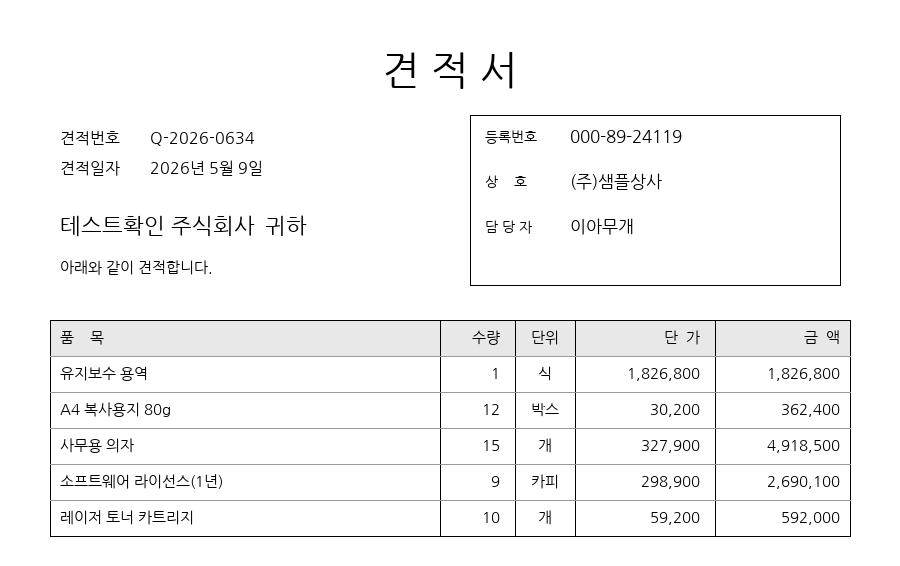

In [7]:
ROW_H = 36
COLS = [("품    목", 60, "la"), ("수량", 500, "ra"), ("단위", 545, "ma"), ("단  가", 700, "ra"), ("금  액", 840, "ra")]
V_LINES = [440, 515, 575, 715]   # 세로 칸막이

def draw_quote_items(d, t, v, top=320) -> int:
    """품목 표. 촘촘한 줄 = 이름-금액을 옆 줄과 짝지어 읽는 실패가 나는 자리 (CORD names 61%).
       표 아래 y 를 돌려준다 — 품목 수가 문서마다 달라서"""
    bottom = top + ROW_H * (len(v["items"]) + 1)
    d.rectangle((50, top, 850, top + ROW_H), fill="#e8e8e8")
    d.rectangle((50, top, 850, bottom), outline="black")
    for x in V_LINES:
        d.line((x, top, x, bottom), fill="black")
    for label, x, anc in COLS:
        put(d, t, (x, top + 10), label, 15, anchor=anc)
    for i, it in enumerate(v["items"]):
        y = top + ROW_H * (i + 1)
        d.line((50, y, 850, y), fill="#999999")
        put(d, t, (60, y + 10), it["name"], 15, name=f"item{i}.name")
        put(d, t, (500, y + 10), str(it["qty"]), 15, name=f"item{i}.qty", kind="num", anchor="ra")
        put(d, t, (545, y + 10), it["unit_name"], 15, anchor="ma")
        put(d, t, (700, y + 10), f"{it['unit_price']:,}", 15, name=f"item{i}.unit_price", kind="num", anchor="ra")
        put(d, t, (840, y + 10), f"{it['amount']:,}", 15, name=f"item{i}.amount", kind="num", anchor="ra")
    return bottom

# 미리보기 — 상단 + 표
_img = Image.new("RGB", (W, H), "white"); _d = ImageDraw.Draw(_img); _t = []
draw_quote_header(_d, _t, _v)
_b = draw_quote_items(_d, _t, _v)
print(len(_t), "개 필드 기록")
_img.crop((0, 0, W, _b + 30))

In [8]:
DIGITS = "영일이삼사오육칠팔구"
SMALL = ["", "십", "백", "천"]
BIG = ["", "만", "억", "조"]

def won_korean(n: int) -> str:
    """11428780 → 일천일백사십이만팔천칠백팔십. 네 자리씩 끊어 만·억·조를 붙인다.
       '일'을 생략하지 않는다(일십·일천) — 위조 방지용 공문서·금융 관행"""
    out = []
    for gi in range(len(BIG)):
        g = (n // 10 ** (4 * gi)) % 10000
        if not g:
            continue
        s = "".join(DIGITS[(g // 10 ** si) % 10] + SMALL[si]
                    for si in range(3, -1, -1) if (g // 10 ** si) % 10)
        out.append(s + BIG[gi])
    return "".join(reversed(out)) or "영"

[(n, won_korean(n)) for n in (11428780, 10, 10005, 100000000, 0)]

[(11428780, '일천일백사십이만팔천칠백팔십'),
 (10, '일십'),
 (10005, '일만오'),
 (100000000, '일억'),
 (0, '영')]

30 개 필드 기록 · ['vat', 'total', 'total_kor']


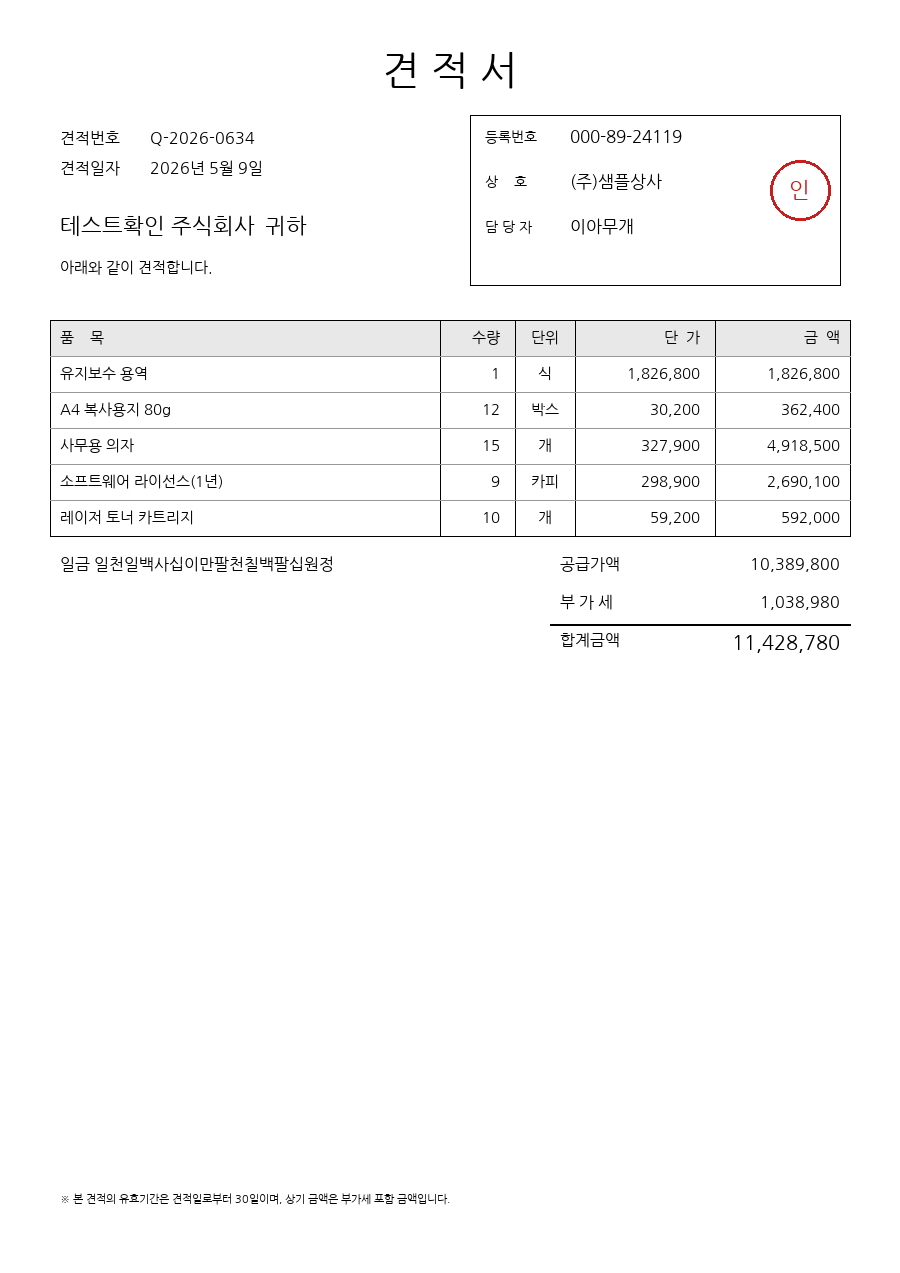

In [9]:
STAMP = (200, 30, 30)

def draw_quote_footer(d, t, v, top):
    """합계 세 줄(검산 재료) · 직인(방해 요소, 기록 안 함) · 작은 각주"""
    rows = [("공급가액", "supply", 16), ("부 가 세", "vat", 16), ("합계금액", "total", 20)]
    for i, (label, key, size) in enumerate(rows):
        y = top + 20 + i * 38
        put(d, t, (560, y), label, 16)
        put(d, t, (840, y), f"{v[key]:,}", size, name=key, kind="num", anchor="ra")
    d.line((550, top + 88, 850, top + 88), fill="black", width=2)
    # 한글 금액 — 같은 값을 다른 문자로 한 번 더. 검산 장치가 숫자 합계와 대조한다
    put(d, t, (60, top + 20), f"일금 {won_korean(v['total'])}원정", 16, name="total_kor")
    # 직인 — 지금은 글자에 겹치지 않게. 글자를 덮는 직인은 열화 단계에서 다룬다
    d.ellipse((770, 160, 830, 220), outline=STAMP, width=3)
    d.text((800, 190), "인", font=font(22), fill=STAMP, anchor="mm")
    put(d, t, (60, H - 80), "※ 본 견적의 유효기간은 견적일로부터 30일이며, 상기 금액은 부가세 포함 금액입니다.", 11)

def draw_quote(v: dict) -> tuple[Image.Image, list[FieldTruth]]:
    """견적서 한 장 — 이미지와 정답 목록"""
    img = Image.new("RGB", (W, H), "white"); d = ImageDraw.Draw(img); t = []
    draw_quote_header(d, t, v)
    bottom = draw_quote_items(d, t, v)
    draw_quote_footer(d, t, v, bottom)
    return img, t

_img, _t = draw_quote(_v)
print(len(_t), "개 필드 기록 ·", [f.name for f in _t[-3:]])
_img

---

# 2. 열화 — 오류를 기다리지 않고 만든다

정상 이미지에서 VLM 오답은 드물다 (CORD 41장에서 합계 오답 0). 단계별로 망가뜨려 실패를 만든다.
**크기는 원본과 같게 유지한다** — 픽셀만 바뀌고 위치는 그대로라 정답 bbox 를 그대로 쓴다.
강도 숫자는 **잠정** — OCR 결과로 조정한다.

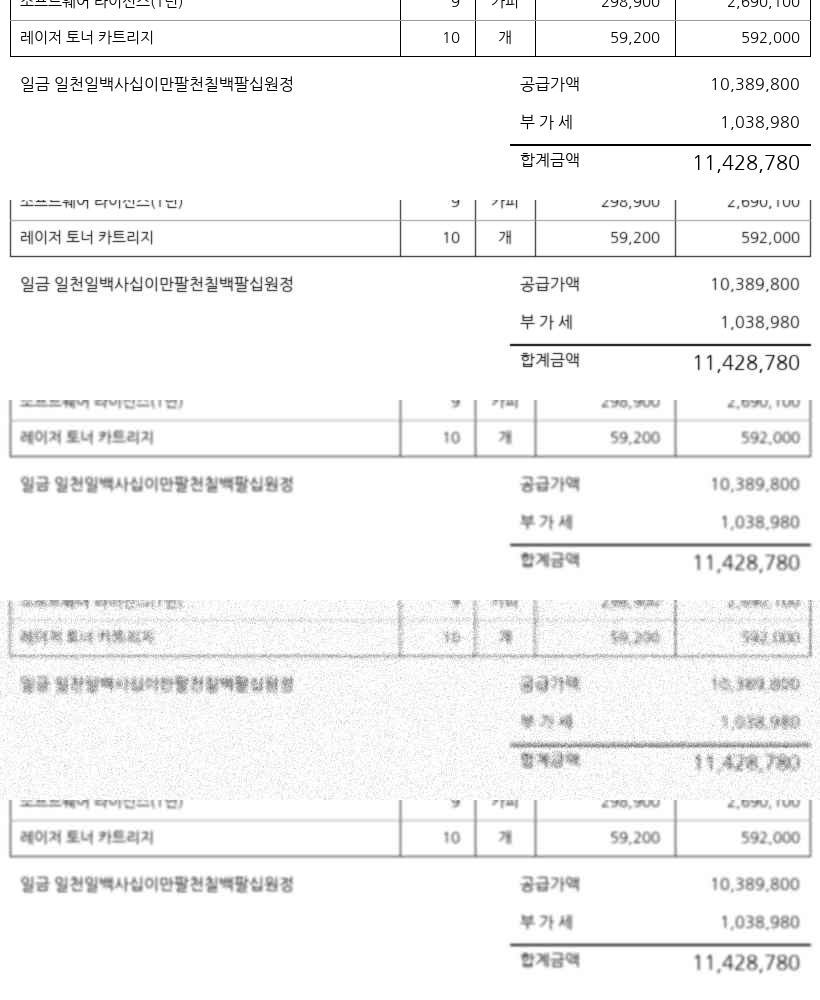

In [10]:
import io
import numpy as np
from PIL import ImageFilter

def _jpeg(img, quality):
    """메신저·메일로 오가며 압축된 이미지"""
    buf = io.BytesIO(); img.save(buf, "JPEG", quality=quality); buf.seek(0)
    return Image.open(buf).convert("RGB")

def degrade(img, level: str, seed: int = 0) -> Image.Image:
    """L0 원본 · L0.5 약한 흔들림 · L1 흔들림+압축 · L2 저해상도+노이즈 · L3 얼룩. seed 고정 → 같은 이미지"""
    rng = np.random.default_rng(seed)
    w, h = img.size
    if level == "L0":
        return img.copy()
    if level == "L0.5":                       # L1 의 절반 — OCR 이 무너지기 직전 구간을 보려고
        return _jpeg(img.filter(ImageFilter.GaussianBlur(0.6)), 60)
    if level == "L1":
        return _jpeg(img.filter(ImageFilter.GaussianBlur(1.2)), 30)
    if level == "L2":
        small = img.resize((w // 3, h // 3), Image.BILINEAR).resize((w, h), Image.BILINEAR)   # 크기 복원 → bbox 유지
        a = np.asarray(small, dtype=np.int16) + rng.normal(0, 18, (h, w, 1)).astype(np.int16)
        return _jpeg(Image.fromarray(np.clip(a, 0, 255).astype(np.uint8)), 40)
    if level == "L3":
        out = degrade(img, "L1", seed).convert("RGBA")
        layer = Image.new("RGBA", (w, h), (0, 0, 0, 0)); ld = ImageDraw.Draw(layer)
        for _ in range(4):
            x, y, r = rng.integers(0, w), rng.integers(0, h), rng.integers(40, 120)
            ld.ellipse((x - r, y - r, x + r, y + r), fill=(120, 80, 40, 90))
        return Image.alpha_composite(out, layer).convert("RGB")
    raise ValueError(level)   # 오타가 조용히 원본으로 넘어가지 않게

# 미리보기 — 같은 영역(표 아래 ~ 합계)을 단계별로
LEVELS = ["L0", "L0.5", "L1", "L2", "L3"]
_box = (40, 480, 860, 680)
_strip = Image.new("RGB", (_box[2] - _box[0], (_box[3] - _box[1]) * len(LEVELS)), "white")
for i, lv in enumerate(LEVELS):
    _strip.paste(degrade(_img, lv, seed=0).crop(_box), (0, i * (_box[3] - _box[1])))
_strip

---

# 3. OCR — 글자와 위치 (로컬 · 무료 · 지어내지 않는다)

In [11]:
import pytesseract

def ocr_tokens(img, lang: str = "kor+eng", psm: int = 3) -> list[dict]:
    """단어마다 글자 · 신뢰도 · 위치. 위치가 나중에 review.csv 의 '이미지 어디' 가 된다.
       psm — 읽기 모드. 깨끗하면 3, 흐리면 6 이 낫다 (E0 실측)"""
    d = pytesseract.image_to_data(img, lang=lang, config=f"--psm {psm}", output_type=pytesseract.Output.DICT)
    out = []
    for i, text in enumerate(d["text"]):
        if text.strip() and float(d["conf"][i]) >= 0:     # 빈 칸 · 구조 표시(-1) 제외
            x, y, w, h = d["left"][i], d["top"][i], d["width"][i], d["height"][i]
            out.append({"text": text, "conf": float(d["conf"][i]), "bbox": (x, y, x + w, y + h)})  # FieldTruth.bbox 와 같은 모양
    return out

_tok = ocr_tokens(_img)
print(len(_tok), "토큰")
[(t["text"], round(t["conf"])) for t in _tok]

147 토큰


[('ry', 41),
 ('시', 42),
 ('=', 81),
 ('AAAS', 59),
 ('—', 34),
 ('Q-2026-0634', 34),
 ('등', 91),
 ('록', 93),
 ('번호', 49),
 ('000-89-24119', 69),
 ('견', 93),
 ('적', 93),
 ('일', 95),
 ('년', 93),
 ('5', 93),
 ('월', 93),
 ('9', 93),
 ('일', 92),
 ('견', 91),
 ('적', 93),
 ('일자', 11),
 ('202644', 78),
 ('5', 88),
 ('월', 90),
 ('9', 93),
 ('일', 92),
 ('시', 21),
 ('(', 54),
 ('주', 46),
 ('샘', 91),
 ('플', 92),
 ('상사', 96),
 ('테', 93),
 ('스', 93),
 ('트', 93),
 ('확', 93),
 ('인', 96),
 ('주식회사', 96),
 ('귀하', 96),
 ('담당자', 78),
 ('이', 92),
 ('아', 92),
 ('무', 93),
 ('개', 93),
 ('아래와', 96),
 ('같이', 93),
 ('견', 93),
 ('적', 92),
 ('합니다.', 95),
 ('품', 93),
 ('목', 92),
 ('수량', 96),
 ('|', 81),
 ('단위', 96),
 ('단가', 65),
 ('금', 92),
 ('액', 92),
 ('유', 93),
 ('지', 93),
 ('보수', 97),
 ('용역', 96),
 ('1|', 76),
 ('A', 76),
 ('1.826.800', 92),
 ('1.826.800', 92),
 ('Ad', 84),
 ('복', 88),
 ('사', 93),
 ('용지', 96),
 ('809', 85),
 ('12', 96),
 ('|', 90),
 ('박스', 87),
 ('30,200', 92),
 ('362,400', 91),
 ('사무용', 84),
 (

In [12]:
import pickle, hashlib

OCR_CACHE = Path("data/ocr_cache.pkl")      # data/ 는 git 제외 — 재생성 가능
_ocr_mem = pickle.loads(OCR_CACHE.read_bytes()) if OCR_CACHE.exists() else {}
_TESS_VER = str(pytesseract.get_tesseract_version())

def ocr_cached(img, psm: int = 3) -> list[dict]:
    """키 = 픽셀 해시 · psm · tesseract 버전. seed 로 키를 잡으면 합성기·열화를 고쳤을 때
       예전 이미지의 OCR 이 조용히 재사용된다. 픽셀이 1개만 바뀌어도 새로 읽는다"""
    key = (hashlib.md5(img.tobytes()).hexdigest(), psm, _TESS_VER)
    if key not in _ocr_mem:
        _ocr_mem[key] = ocr_tokens(img, psm=psm)
    return _ocr_mem[key]

def save_ocr_cache():
    OCR_CACHE.write_bytes(pickle.dumps(_ocr_mem))

print(f"OCR 캐시 {len(_ocr_mem)}건 · tesseract {_TESS_VER}")

OCR 캐시 110건 · tesseract 5.5.2


In [13]:
import re

# ★ 채점 전용 — 정답 bbox 를 쓴다. 판정 쪽(정답 없이 VLM 값의 근거 찾기)은 따로 만들고 이걸 쓰지 않는다
# ★ 공정성: 정답 위치 안의 토큰을 모으므로 "배치를 완벽히 아는 OCR" — OCR 에 유리한 상한이다

def norm(s: str, kind: str) -> str:
    """비교용. 표 칸막이 '|' 제거. 숫자형은 구분자(쉼표→점 혼동 흡수)만 지우고 문자는 남긴다 — '년'→'44' 는 진짜 오류"""
    s = s.replace("|", "")
    return re.sub(r"[\s,.\-]", "", s) if kind == "num" else re.sub(r"\s", "", s)

def ocr_in_box(tokens, bbox, pad: int = 4) -> str:
    """중심점이 박스 안에 든 토큰을 왼쪽부터 이어 붙인다. OCR 의 읽기 순서는 블록이 섞여 믿지 않는다"""
    x1, y1, x2, y2 = bbox
    hit = [t for t in tokens
           if x1 - pad <= (t["bbox"][0] + t["bbox"][2]) / 2 <= x2 + pad
           and y1 - pad <= (t["bbox"][1] + t["bbox"][3]) / 2 <= y2 + pad]
    return " ".join(t["text"] for t in sorted(hit, key=lambda t: t["bbox"][0]))

def overlap(a, b) -> float:
    """교집합 ÷ 작은 박스 넓이. IoU 가 아닌 이유 — 중복 읽기는 박스 모양이 달라서
       ('5' 가 12×30 과 7×12 로 두 번) 작은 쪽이 큰 쪽 안에 통째로 들어가도 IoU 는 0.23 이다"""
    ix = max(0, min(a[2], b[2]) - max(a[0], b[0])); iy = max(0, min(a[3], b[3]) - max(a[1], b[1]))
    small = min((a[2] - a[0]) * (a[3] - a[1]), (b[2] - b[0]) * (b[3] - b[1]))
    return ix * iy / small if small else 0

# ★ 쓰지 않음 — 실패 기록용. 위치로 중복을 지우면 이웃 글자까지 지운다 (아래 관찰 참고)
def dedupe(tokens, min_overlap: float = 0.5) -> tuple[list[dict], list[dict]]:
    """tesseract 는 같은 줄을 두 번 읽기도 한다 (L0 날짜: '년' 과 '202644' 를 둘 다 냄).
       겹치면 OCR 이 더 확신한 쪽만 남긴다 — 정답이 아니라 OCR 자신의 conf 로 고르므로 판정 쪽에도 쓸 수 있다.
       버린 것도 돌려준다 — 중복 읽기 자체가 OCR 의 약점이라 기록한다"""
    kept, dropped = [], []
    for t in sorted(tokens, key=lambda t: -t["conf"]):
        (kept if all(overlap(t["bbox"], k["bbox"]) < min_overlap for k in kept) else dropped).append(t)
    return kept, dropped

OCR_PSMS = (3, 6)

def score_ocr(img, truths) -> list[dict]:
    """모드별 결과를 따로 남기고, 하나라도 맞으면 ok — OCR 에 가장 유리한 상한.
       실무에선 어느 모드를 믿을지 모르므로 실제 OCR 보다 후하다. 그래도 VLM 이 이기면 반론이 없다"""
    toks = {p: ocr_cached(img, psm=p) for p in OCR_PSMS}
    rows = []
    for f in truths:
        r = {"field": f.name, "kind": f.kind, "truth": f.value}
        for p, T in toks.items():
            o = ocr_in_box(T, f.bbox)
            r[f"ocr_p{p}"], r[f"ok_p{p}"] = o, norm(o, f.kind) == norm(f.value, f.kind)
        r["ok"] = any(r[f"ok_p{p}"] for p in OCR_PSMS)
        rows.append(r)
    return rows

import pandas as pd
_s = pd.DataFrame(score_ocr(_img, _t))
print(f"L0 OCR 판독: psm3 {_s.ok_p3.sum()}/{len(_s)} · psm6 {_s.ok_p6.sum()}/{len(_s)} · 유리한 쪽 {_s.ok.sum()}/{len(_s)}")
save_ocr_cache()
_s[~_s.ok]

L0 OCR 판독: psm3 27/30 · psm6 25/30 · 유리한 쪽 27/30


,field,kind,truth,ocr_p3,ok_p3,ocr_p6,ok_p6,ok
1,date,num,2026년 5월 9일,202644 년 5 5 월 월 9 9 일 일,False,2026 년 년 5 5 월 월 08 9 일,False,False
4,supplier,text,(주)샘플상사,( 주 샘 플 상사,False,( 주 샘 플 상사,False,False
10,item1.name,text,A4 복사용지 80g,Ad 복 사 용지 809,False,서 복 사지 809,False,False


### E0 — 단계별 OCR 판독 (RQ1 의 OCR 쪽)

견적서 10장 × 5단계 × psm 2개. 모드별 결과를 따로 남기고, **둘 중 하나라도 맞으면 OCR 이 맞은 것** 으로 친다 —
OCR 에 가장 유리한 기준선이다. 그래도 VLM 이 이기면 "OCR 을 약하게 만들었다" 는 반론이 없다.

In [14]:
N_DOCS = 10
rows = []
for seed in range(N_DOCS):
    img, truths = draw_quote(quote_values(random.Random(seed)))
    for lv in LEVELS:
        for r in score_ocr(degrade(img, lv, seed=seed), truths):
            rows.append({"doc": seed, "level": lv, **r})
E0 = pd.DataFrame(rows)

def pct(s):   # 분모 함께
    return f"{s.mean():.1%} ({s.sum()}/{len(s)})"

for col, title in [("ok_p3", "psm 3"), ("ok_p6", "psm 6"), ("ok", "★ 유리한 쪽 (OCR 기준선)")]:
    print(title)
    print(E0.pivot_table(index="kind", columns="level", values=col, aggfunc=pct)[LEVELS], "\n")

psm 3
level               L0             L0.5              L1            L2  \
kind                                                                    
num    92.0% (149/162)  90.1% (146/162)  17.9% (29/162)  0.0% (0/162)   
text     77.0% (57/74)    82.4% (61/74)   27.0% (20/74)   0.0% (0/74)   

level            L3  
kind                 
num    4.3% (7/162)  
text   10.8% (8/74)   

psm 6
level               L0             L0.5               L1            L2  \
kind                                                                     
num    80.9% (131/162)  86.4% (140/162)  66.7% (108/162)  1.2% (2/162)   
text     56.8% (42/74)    79.7% (59/74)    43.2% (32/74)   0.0% (0/74)   

level              L3  
kind                   
num    37.7% (61/162)  
text    29.7% (22/74)   

★ 유리한 쪽 (OCR 기준선)
level               L0             L0.5               L1            L2  \
kind                                                                     
num    93.2% (151/162)  91.4% (148/162)  69.

### ★ 관찰 — 코드로 "한 번만 읽게" 했더니 더 나빠졌다

| | L0 숫자형 | L0 글자형 |
|---|---|---|
| OCR 그대로 (`ok_raw`) | 92.0% (149/162) | 77.0% (57/74) |
| 중복 제거 후 (`ok`) | 91.4% (148/162) | 74.3% (55/74) |

- tesseract 는 같은 줄을 **두 번, 서로 다르게** 읽는다 — 944칸 중 37칸 (날짜: `년` 과 `202644`)
- 위치로 중복을 지우면 **옆 글자까지 지운다** — 한글 박스가 세로로 길어 이웃과 겹친다 (`유지보수` → `지보수`)
- IoU 기준은 중복을 못 잡았고(박스 모양이 달라 0.23), 포함 비율 기준은 이웃을 잡았다. **위치만으로는 못 가른다**
- 읽기 모드(psm)를 바꿔도 중복은 남는다 (아래 표, 10장)

| psm | L0 판독 | L1 판독 |
|---|---|---|
| 3 (기본, 자동 배치) | 87.3% | 20.8% |
| 6 (한 덩어리) | 73.3% | **59.3%** |

→ **설정 하나가 모든 단계에서 낫지 않다.** 깨끗하면 3, 흐리면 6. 그런데 실무에선 이미지가 어느 단계인지 모른다.
**OCR 의 한계는 "못 읽음" 만이 아니라 "어떻게 읽을지 정해야 함"** 이다 — VLM 이 넘어서야 할 선.

---

# 4. 검증 장치 — 정답을 모른다

입력은 필드 이름 → 문자열 dict 하나뿐이다. **정답을 받을 인자가 없다.**
장치 시험에는 정답 값을 이 모양으로 넣는다 — "완벽하게 읽은 결과" 를 흉내 내는 것이지 정답을 몰래 보는 게 아니다.
정답에서 장치가 100% 통과해야, VLM 출력의 검산 실패를 진짜 신호로 읽을 수 있다 (CORD 131/131 과 같은 절차).

In [15]:
@dataclass
class CheckResult:
    name: str
    passed: bool | None     # None = 검사할 수 없음 (비었거나 해석 불가). 0 으로 읽어 조용히 통과시키지 않는다
    detail: str
    fields: list[str]       # 실패 시 review.csv 에 "어느 칸을 보라" 로 찍힌다

def parse_amount(s) -> int | None:
    """마지막 구분자 뒤 1~2자리 = 소수점, 3자리 = 천단위 (CORD 파서 P3 와 같은 규칙).
       쉼표↔점 혼동에 안 깨진다. 숫자가 아닌 게 섞이면 억지로 뽑지 않고 None"""
    if s is None:
        return None
    t = re.sub(r"[\s원₩]", "", str(s))
    m = re.fullmatch(r"(.*?)(?:[.,](\d{1,2}))?", t)
    if m.group(2) and int(m.group(2)) != 0:      # 원화에 소수는 없다
        return None
    t = re.sub(r"[.,]", "", m.group(1))
    return int(t) if t.isdigit() else None

SMALL_U = {"십": 10, "백": 100, "천": 1000}
BIG_U = {"만": 10**4, "억": 10**8, "조": 10**12}

def kor_to_int(s) -> int | None:
    """won_korean 의 역방향. 앞 '일금' · 뒤 '원정' 은 위치를 고정해 뗀다 — 그냥 지우면 숫자 '일' 까지 지운다.
       모르는 글자가 있으면 None — 건너뛰고 계산하면 틀린 금액이 '해석된 값' 이 된다"""
    if not s:
        return None
    s = re.sub(r"^일금|원정?$|\s", "", str(s))
    total = group = num = 0
    for ch in s:
        if ch in DIGITS:
            num = DIGITS.index(ch)
        elif ch in SMALL_U:
            group += (num or 1) * SMALL_U[ch]; num = 0
        elif ch in BIG_U:
            total += (group + num or 1) * BIG_U[ch]; group = num = 0
        else:
            return None
    return total + group + num

# 확인 — 경계 사례
_cases = ["1,826,800", "1.826.800", "1,826,800.00", "1826800원", "₩ 1,826,800", "1,826,800.50", "202644년", "Ad", None]
print([(c, parse_amount(c)) for c in _cases])
_k = ["일금 일천일백사십이만팔천칠백팔십원정", "일십", "일만오", "일억", "일천일벡사십이만"]
print([(c, kor_to_int(c)) for c in _k])
print("왕복:", all(kor_to_int(won_korean(n)) == n for n in [1, 10, 105, 10005, 11428780, 100000000, 987654321]))

[('1,826,800', 1826800), ('1.826.800', 1826800), ('1,826,800.00', 1826800), ('1826800원', 1826800), ('₩ 1,826,800', 1826800), ('1,826,800.50', None), ('202644년', None), ('Ad', None), (None, None)]
[('일금 일천일백사십이만팔천칠백팔십원정', 11428780), ('일십', 10), ('일만오', 10005), ('일억', 100000000), ('일천일벡사십이만', None)]
왕복: True


In [16]:
def _cr(name, ok, detail, fields):
    return CheckResult(name, ok, detail, fields)

def check_year(x) -> CheckResult:
    """⑧ 날짜 연도 = 문서번호 연도. 같은 정보를 다른 칸에 두 번 쓴 것 — 한글 금액 줄과 같은 원리.
       1일차 L2 에서 2026→2020 이 실재하는 날짜라 ⑦ 을 통과했다. 문서번호에 연도가 없는 양식이면 None"""
    d = re.search(r"(\d{4})\D", x.get("date") or "")
    n = re.search(r"(20\d{2})", x.get("doc_no") or "")
    if not (d and n):
        return CheckResult("날짜=문서번호 연도", None, f"{x.get('date')} / {x.get('doc_no')}", ["date", "doc_no"])
    # ★ 반증 전용 — 일치해도 신호가 아니다. 1일차 L2 에서 VLM 이 두 칸 다 2026→2020 으로 같은 착시를 해 통과했고,
    #   그 통과가 신호가 되자 놓친 오답이 9→18 로 늘었다. 같은 VLM 이 같은 이미지에서 읽은 값끼리의 일치는 독립 증거가 아니다
    ok = d.group(1) == n.group(1)
    return CheckResult("날짜=문서번호 연도", None if ok else False,
                       f"{d.group(1)} vs {n.group(1)}" + (" · 일치는 반증 실패일 뿐" if ok else ""), ["date", "doc_no"])

def check_quote(x: dict) -> list[CheckResult]:
    """견적서 검사 8종. 입력은 읽은 값 하나뿐 — 정답 인자 없음.
       재료 하나라도 None 이면 결과도 None(검사 불가). 글자형(품목명·회사명)은 못 잡는다 → OCR 근거 대조의 몫"""
    A = lambda k: parse_amount(x.get(k))
    n = len({k.split(".")[0] for k in x if k.startswith("item")})
    out = []
    for i in range(n):                                                    # ① 줄 안의 숫자 오독 — 몇 번째 줄인지까지
        u, q, a = A(f"item{i}.unit_price"), A(f"item{i}.qty"), A(f"item{i}.amount")
        ok = None if None in (u, q, a) else u * q == a
        out.append(_cr(f"단가×수량[{i}]", ok, f"{u}×{q} vs {a}", [f"item{i}.unit_price", f"item{i}.qty", f"item{i}.amount"]))
    amts, s = [A(f"item{i}.amount") for i in range(n)], A("supply")      # ② 품목 누락 · 이웃 줄과 섞어 읽기
    ok = None if None in amts + [s] else sum(amts) == s
    out.append(_cr("Σ품목=공급가액", ok, f"Σ{sum(a or 0 for a in amts)} vs {s}", [f"item{i}.amount" for i in range(n)] + ["supply"]))
    v, t = A("vat"), A("total")
    out.append(_cr("부가세=10%", None if None in (s, v) else abs(s * 0.1 - v) <= 1, f"{s}×10% vs {v}", ["supply", "vat"]))   # ③ 절사·반올림 ±1원
    out.append(_cr("공급가+부가세=합계", None if None in (s, v, t) else s + v == t, f"{s}+{v} vs {t}", ["supply", "vat", "total"]))  # ④
    k = kor_to_int(x.get("total_kor"))                                    # ⑤ 같은 값을 다른 문자로 — 합계 날조
    out.append(_cr("한글금액=합계", None if None in (k, t) else k == t, f"{k} vs {t}", ["total_kor", "total"]))
    d = re.sub(r"\D", "", x.get("supplier_brn") or "")                    # ⑥ 번호 한 자리 바꿔치기
    out.append(_cr("사업자번호 체크섬", None if len(d) != 10 else brn_check_digit([int(c) for c in d[:9]]) == int(d[9]), d, ["supplier_brn"]))
    m = re.search(r"(\d{4})\D+(\d{1,2})\D+(\d{1,2})", x.get("date") or "")   # ⑦ 2월 30일 같은 날짜. 표기 형식은 안 따진다
    try:
        ok = bool(m) and date(*map(int, m.groups())) is not None
    except ValueError:
        ok = False
    out.append(_cr("날짜 실재", ok if m else None, x.get("date"), ["date"]))
    out.append(check_year(x))                                             # ⑧
    return out

# 확인 ① — 정답 10장에서 실패가 없어야 한다(⑧ 은 반증 전용이라 일치 = None). 하나라도 실패하면 장치 버그
_fail = []
for seed in range(N_DOCS):
    _, tr = draw_quote(quote_values(random.Random(seed)))
    _fail += [(seed, c.name, c.detail) for c in check_quote({f.name: f.value for f in tr})
          if c.passed is False or (c.passed is None and c.name != "날짜=문서번호 연도")]
print(f"정답 10장: 검사 실패/불가 {len(_fail)}건", _fail)

# 확인 ② — 합계 한 자리를 바꾸면 ④ · ⑤ 가 잡는다
_x = {f.name: f.value for f in _t}
_x["total"] = _x["total"].replace("4", "7", 1)
[(c.name, c.passed, c.detail) for c in check_quote(_x) if c.passed is not True]

정답 10장: 검사 실패/불가 0건

 []


[('공급가+부가세=합계', False, '10389800+1038980 vs 11728780'),
 ('한글금액=합계', False, '11428780 vs 11728780'),
 ('날짜=문서번호 연도', None, '2026 vs 2026 · 일치는 반증 실패일 뿐')]

In [17]:
def ocr_lines(tokens, y_tol: int = 8) -> list[list[dict]]:
    """세로 중심이 y_tol 안인 토큰끼리 한 줄로. OCR 읽기 순서는 블록이 섞여 믿지 않고 위치로 줄을 다시 만든다"""
    lines = []
    for t in sorted(tokens, key=lambda t: (t["bbox"][1] + t["bbox"][3]) / 2):
        cy = (t["bbox"][1] + t["bbox"][3]) / 2
        if lines and abs(lines[-1][0]["_cy"] - cy) <= y_tol:
            lines[-1].append({**t, "_cy": cy})
        else:
            lines.append([{**t, "_cy": cy}])
    return [sorted(l, key=lambda t: t["bbox"][0]) for l in lines]

def ground(value: str, kind: str, token_sets: list[list[dict]], max_span: int = 12):
    """판정 쪽 — 정답 없이 OCR 전체에서 값을 찾는다. 찾으면 위치(review.csv 의 '이미지 어디'), 못 찾으면 None.
       None = 이미지 글자에 없는 값 = 지어냈을 수 있음. 정규화는 채점과 같은 norm — 기준이 어긋나지 않게"""
    target = norm(value or "", kind)
    if not target:
        return None
    for toks in token_sets:                       # psm 3 · 6 어느 쪽에서든 찾으면 근거
        for line in ocr_lines(toks):
            for i in range(len(line)):
                for j in range(i + 1, min(i + max_span, len(line)) + 1):   # 쪼개진 한글을 이어 붙인다
                    if norm("".join(t["text"] for t in line[i:j]), kind) == target:
                        bs = [t["bbox"] for t in line[i:j]]
                        return (min(b[0] for b in bs), min(b[1] for b in bs), max(b[2] for b in bs), max(b[3] for b in bs))
    return None

# 확인 ① — 완벽하게 읽은 값이 단계별로 근거를 몇 % 찾나 (못 찾으면 = 맞는데 의심받는 헛경보 재료)
_g = []
for seed in range(N_DOCS):
    img, tr = draw_quote(quote_values(random.Random(seed)))
    for lv in LEVELS:
        im = degrade(img, lv, seed=seed)
        sets = [ocr_cached(im, psm=p) for p in OCR_PSMS]
        _g += [{"level": lv, "kind": f.kind, "found": ground(f.value, f.kind, sets) is not None} for f in tr]
print(pd.DataFrame(_g).pivot_table(index="kind", columns="level", values="found", aggfunc=pct)[LEVELS], "\n")

# 확인 ② — 지어낸 합계는 근거가 없어야 한다
_sets = [ocr_cached(_img, psm=p) for p in OCR_PSMS]
print("진짜 합계 :", _x_true := next(f.value for f in _t if f.name == "total"), "→", ground(_x_true, "num", _sets))
print("지어낸 합계:", "11,728,780", "→", ground("11,728,780", "num", _sets))
save_ocr_cache()
print("수량 '1'  :", ground("1", "num", _sets), "← 짧은 값은 아무 데서나 찾힌다")

level               L0             L0.5               L1            L2  \
kind                                                                     
num    93.2% (151/162)  92.0% (149/162)  72.2% (117/162)  3.1% (5/162)   
text     70.3% (52/74)    75.7% (56/74)    45.9% (34/74)   0.0% (0/74)   

level              L3  
kind                   
num    48.1% (78/162)  
text    29.7% (22/74)   

진짜 합계 : 11,428,780 → (735, 635, 839, 653)
지어낸 합계: 11,728,780 → None
수량 '1'  : (493, 368, 497, 379) ← 짧은 값은 아무 데서나 찾힌다


---

# 5. 판정 — 자동 / 검토

규칙은 사용자 결정 (`research.md` 2026-10-03 판정 규칙). 아직 고르지 않은 것은 **인자로 열어두고 데이터로 고른다.**

| 인자 | 선택지 | 무엇 |
|---|---|---|
| `no_ground` | `"weak"` / `"red"` | Q3 — OCR 근거 없음 = 신호 없음 / 빨간불 |
| `min_signals` | 1 / 2 | Q2 — 자동에 필요한 통과 신호 수 |
| `min_len` | 1 / N | Q4 — 짧은 값의 OCR 근거를 신호로 칠지 (`"1"` 은 아무 데서나 찾힌다) |

In [18]:
TEXT_FIELDS = {"client", "supplier", "manager", "total_kor"}

def kind_of(field: str) -> str:
    """필드 이름만 보고 정한다 — 정답의 kind 가 아니라 양식(스키마) 정보라 판정이 알아도 된다"""
    return "text" if field in TEXT_FIELDS or field.endswith(".name") else "num"

def parsable(field: str, v: str) -> bool:
    """읽을 수 있는 모양인가 — Q2: 해석 불가인 칸 자체는 검토"""
    if field == "total_kor":
        return kor_to_int(v) is not None
    if field == "supplier_brn":
        return len(re.sub(r"\D", "", v)) == 10
    if field == "date":
        return re.search(r"\d{4}\D+\d{1,2}\D+\d{1,2}", v) is not None
    if field == "doc_no" or kind_of(field) == "text":
        return True
    return parse_amount(v) is not None

@dataclass
class FieldVerdict:
    field: str
    value: str | None
    verdict: str              # "auto" | "review"
    reasons: list[str]        # 사람이 CSV 에서 왜 의심받았는지 전부 본다
    bbox: tuple | None        # OCR 근거 위치 — 없으면 비어 있다
    signals: int              # 통과한 신호 수 (검산 통과 + OCR 근거)

def ground_strict(value, kind, token_sets):
    """psm 마다 따로 찾는다. 한쪽에서만 찾히면 '모드 불일치' — OCR 끼리 의견이 갈린 애매한 글자.
       1일차: VLM '이아무게' 를 psm3 은 같은 오독으로, psm6 은 '이아무개' 로 읽었다"""
    found = [b for b in (ground(value, kind, [T]) for T in token_sets) if b]
    if not found:
        return None, "없음"
    return found[0], ("일치" if len(found) == len(token_sets) else "모드 불일치")

def judge(x: dict, checks: list[CheckResult], token_sets,
          no_ground: str = "weak", min_signals: int = 1, min_len: int = 1,
          ocr_conflict: str = "weak") -> list[FieldVerdict]:
    """★ 정답 인자 없음. 기본값은 검토 — 자동은 통과한 신호가 있어야만 받는다 (Q2)"""
    out = []
    for f, v in x.items():
        if v in (None, ""):
            out.append(FieldVerdict(f, v, "review", ["값 없음"], None, 0)); continue
        k, reasons = kind_of(f), []
        mine = [c for c in checks if f in c.fields]
        reasons += [f"검산 실패: {c.name} ({c.detail})" for c in mine if c.passed is False]   # Q1 걸린 칸만
        sig = sum(c.passed is True for c in mine)
        if not parsable(f, v):
            reasons.append("해석 불가")
        b, agree = ground_strict(v, k, token_sets)
        if b is None:
            if no_ground == "red":                                                            # Q3 (a)
                reasons.append("OCR 근거 없음")
        elif ocr_conflict == "strict" and agree == "모드 불일치":
            pass                             # 위치는 남기되 신호로 안 친다 — 빨간불도 아니다
        elif len(norm(v, k)) >= min_len:     # 짧은 값의 근거는 신호로 안 칠 뿐, '근거 없음' 은 아니다 (Q4)
            sig += 1
        if sig < min_signals:
            reasons.append(f"통과한 신호 {sig}개")
        out.append(FieldVerdict(f, v, "review" if reasons else "auto", reasons, b, sig))
    return out

# 확인 — 완벽하게 읽은 값을 넣는다. 전부 맞는 값이므로 검토로 간 것 = 헛경보
POLICIES = [(ng, ms, ml) for ng in ("weak", "red") for ms in (1, 2) for ml in (1, 3)]
_j = []
for seed in range(N_DOCS):
    img, tr = draw_quote(quote_values(random.Random(seed)))
    x = {f.name: f.value for f in tr}
    chk = check_quote(x)
    for lv in ("L0", "L1", "L2"):
        sets = [ocr_cached(degrade(img, lv, seed=seed), psm=p) for p in OCR_PSMS]
        for ng, ms, ml in POLICIES:
            _j += [{"level": lv, "policy": f"{ng}/신호{ms}/길이{ml}", "review": v.verdict == "review"}
                   for v in judge(x, chk, sets, ng, ms, ml)]
print("완벽하게 읽은 값의 헛경보율 (검토로 간 비율) — 낮을수록 좋다")
save_ocr_cache()
pd.DataFrame(_j).pivot_table(index="policy", columns="level", values="review", aggfunc=pct)[["L0", "L1", "L2"]]

완벽하게 읽은 값의 헛경보율 (검토로 간 비율) — 낮을수록 좋다


level,L0,L1,L2
policy,,,
red/신호1/길이1,14.0% (33/236),36.0% (85/236),97.9% (231/236)
red/신호1/길이3,14.0% (33/236),36.0% (85/236),97.9% (231/236)
red/신호2/길이1,38.6% (91/236),50.8% (120/236),97.9% (231/236)
red/신호2/길이3,53.0% (125/236),52.5% (124/236),100.0% (236/236)
weak/신호1/길이1,6.8% (16/236),16.5% (39/236),31.4% (74/236)
weak/신호1/길이3,6.8% (16/236),16.5% (39/236),31.4% (74/236)
weak/신호2/길이1,38.6% (91/236),50.8% (120/236),70.8% (167/236)
weak/신호2/길이3,53.0% (125/236),52.5% (124/236),72.9% (172/236)


---

# 6. 채점 · 보고 — ★ 정답은 여기서 처음 쓴다

판정이 다 끝난 결과에만 정답을 대어본다. 맞음/틀림 × 자동/검토 → **정상 · 오탐 · 놓친 오답 · 잡음**.
요약 % 는 **전체 칸을 분모로**, 건수를 같이 찍는다. 사람용 CSV 에는 정답 열을 넣지 않는다.

In [19]:
from dataclasses import asdict

def correct(field, v, truth) -> bool:
    """필드 종류별 같은 값인가. 날짜는 표기 무관(2026년 5월 9일 = 2026-05-09), 금액은 숫자로"""
    if v in (None, "") or truth is None:          # null 은 '읽은 값' 이 아니다 · 정답에 없는 칸(지어낸 줄)은 틀림
        return False
    if field == "date":
        ymd = lambda s: (m := re.search(r"(\d{4})\D+(\d{1,2})\D+(\d{1,2})", s)) and tuple(map(int, m.groups()))
        return ymd(v) == ymd(truth)
    if field == "total_kor":
        return kor_to_int(v) == kor_to_int(truth)
    if kind_of(field) == "text" or field in ("doc_no", "supplier_brn"):
        return norm(v, kind_of(field)) == norm(truth, kind_of(field))
    return parse_amount(v) == parse_amount(truth)

OUTCOME = {(True, "auto"): "정상", (True, "review"): "오탐", (False, "auto"): "놓친 오답", (False, "review"): "잡음"}

def score(verdicts, truths, **meta) -> list[dict]:
    """정답에 있는데 추출 안 된 칸을 '추출 안 됨 · 검토' 로 채운다 — 빼먹은 줄이 분모에서 조용히 사라지지 않게"""
    tv = {f.name: f.value for f in truths}
    seen = {v.field for v in verdicts}
    verdicts = verdicts + [FieldVerdict(f, None, "review", ["추출 안 됨"], None, 0) for f in tv if f not in seen]
    return [{**meta, **asdict(v), "truth": tv.get(v.field), "correct": (ok := correct(v.field, v.value, tv.get(v.field))),
             "outcome": OUTCOME[(ok, v.verdict)]} for v in verdicts]

def report(df, by=("method", "level")):
    rate = lambda name: (name, lambda s: f"{(s == name).mean():.1%} ({(s == name).sum()}/{len(s)})")
    return df.groupby(list(by))["outcome"].agg([("검사", "size"),
        ("의심", lambda s: f"{s.isin(['오탐', '잡음']).mean():.1%} ({s.isin(['오탐', '잡음']).sum()}/{len(s)})"),
        rate("오탐"), rate("놓친 오답")])

HUMAN_COLS = ["doc_id", "doc_type", "level", "method", "field", "value", "verdict", "reasons", "bbox"]

def write_csv(df, name):
    """_review.csv = 사람용(검토 칸만, 정답 없음) · _scored.csv = 채점용(전부)
       ★ '추출 안 됨' 은 정답을 봐야 아는 칸이라 사람용에서 뺀다 — 실무에선 검산 실패로 드러나야 한다"""
    human = df[(df.verdict == "review") & (df.reasons.map(lambda r: r != ["추출 안 됨"]))]
    human[HUMAN_COLS].to_csv(f"data/{name}_review.csv", index=False)
    df.to_csv(f"data/{name}_scored.csv", index=False)

# 시연 — 가짜 VLM 출력: 정답 10장(L1)에 오류 셋을 심는다
def fake_vlm(seed, tr):
    x = {f.name: f.value for f in tr}
    if seed == 3:                                   # 합계 한 자리
        x["total"] = x["total"][:-3] + str((int(x["total"][-3]) + 1) % 10) + x["total"][-2:]
    if seed == 5:                                   # 품목 한 줄 통째로 누락
        x = {k: v for k, v in x.items() if not k.startswith("item1.")}
    if seed == 7:                                   # 사업자번호 끝자리
        x["supplier_brn"] = x["supplier_brn"][:-1] + str((int(x["supplier_brn"][-1]) + 1) % 10)
    return x

_rows = []
for seed in range(N_DOCS):
    img, tr = draw_quote(quote_values(random.Random(seed)))
    im = degrade(img, "L1", seed=seed)
    sets = [ocr_cached(im, psm=p) for p in OCR_PSMS]
    x = fake_vlm(seed, tr)
    for ng in ("weak", "red"):
        _rows += score(judge(x, check_quote(x), sets, no_ground=ng), tr,
                       doc_id=f"quote_{seed:03d}", doc_type="quote", level="L1", method=f"가짜VLM/{ng}")
save_ocr_cache()
DEMO = pd.DataFrame(_rows)
write_csv(DEMO[DEMO.method == "가짜VLM/weak"], "demo")
print(report(DEMO), "\n")
print("심은 오류 3건이 어디로 갔나 (weak)")
DEMO[(DEMO.method == "가짜VLM/weak") & ~DEMO.correct][["doc_id", "field", "value", "truth", "verdict", "outcome", "reasons"]]

                   검사              의심              오탐         놓친 오답
method     level                                                   
가짜VLM/red  L1     236  39.0% (92/236)  36.4% (86/236)  0.0% (0/236)
가짜VLM/weak L1     236  20.8% (49/236)  18.2% (43/236)  0.0% (0/236) 

심은 오류 3건이 어디로 갔나 (weak)


,doc_id,field,value,truth,verdict,outcome,reasons
160,quote_003,total,"9,220,300","9,220,200",review,잡음,[검산 실패: 공급가+부가세=합계 (8382000+838200 vs 9220300)...
250,quote_005,item1.name,NaN,사무용 의자,review,잡음,[추출 안 됨]
251,quote_005,item1.qty,NaN,15,review,잡음,[추출 안 됨]
252,quote_005,item1.unit_price,NaN,"110,200",review,잡음,[추출 안 됨]
253,quote_005,item1.amount,NaN,"1,653,000",review,잡음,[추출 안 됨]
319,quote_007,supplier_brn,000-18-60912,000-18-60911,review,잡음,"[검산 실패: 사업자번호 체크섬 (0001860912), 통과한 신호 0개]"


---

# 7. VLM — Groq `qwen/qwen3.8-27b` (오픈소스 가중치)

Gemini 무료는 하루 20건이라 실험 규모가 안 나온다. Groq 는 하루 토큰 200k ≈ 90장 (2026-09-07 실측).
가중치가 공개돼 있어 외부 API 를 못 쓰는 환경이면 같은 모델을 사내에 올릴 수 있다.

In [20]:
import os, json, base64, httpx

def env(name: str) -> str:
    """환경변수 → 이 저장소의 .env → EXTRA_ENV_FILE (01 노트북과 같다). 개인 경로를 코드에 박지 않는다"""
    if v := os.environ.get(name):
        return v
    paths = [Path("../backend/.env"), Path("../.env")]
    if extra := os.environ.get("EXTRA_ENV_FILE"):
        paths.append(Path(extra).expanduser())
    for path in paths:
        if path.exists() and (m := re.search(rf"^{name}=(.+)$", path.read_text(), re.M)):
            return m.group(1).strip().strip("\"'")
    raise RuntimeError(f"{name} 를 찾을 수 없습니다. backend/.env 에 넣으세요.")

GROQ_KEY, VLM_MODEL = env("GROQ_API_KEY"), "qwen/qwen3.8-27b"

# V0 — 장치 없는 평범한 사용법. 키 이름을 정답과 맞춰 flatten 뒤 바로 판정·채점에 넣는다
# ★ unit_price — "unit" 은 VLM 이 단위(식·박스)로 읽었다. 안팎 이름을 같게 둬야 두 뜻이 섞이지 않는다 (첫 호출)
PROMPT_V0 = """이 견적서 이미지에서 아래 JSON 을 추출하라. JSON 만 출력하라.
{"doc_no": "", "date": "", "client": "", "supplier": "", "supplier_brn": "", "manager": "",
 "items": [{"name": "", "qty": "", "unit_price": "", "amount": ""}],
 "supply": "", "vat": "", "total": "", "total_kor": ""}"""

# V1 — 스키마는 V0 과 같게(차이가 지시문 하나여야 효과를 말할 수 있다). 틀은 V0 에서 잘라 붙인다 — 손으로 다시 쓰면 오타가 비교를 깬다
# 규칙 2 는 1일차 핵심 문제(잘못 읽은 단가로 금액을 계산해 검산 통과)를 직접 겨냥한다
PROMPT_V1 = """이 견적서 이미지에서 아래 JSON 을 추출하라. JSON 만 출력하라.
규칙:
1. 이미지에 보이는 글자를 그대로 옮겨라. 숫자 형식·쉼표·표기를 바꾸지 마라.
2. 계산하지 마라. 다른 칸의 값으로 추론하거나 계산해서 채우지 마라.
3. 확실히 읽을 수 없는 칸은 추측하지 말고 null 로 둬라.
""" + PROMPT_V0.split("JSON 만 출력하라.\n", 1)[1]

def to_png_b64(img) -> str:
    """PNG(무손실) — JPEG 로 보내면 전송 중 압축이 한 번 더 들어가 우리가 만든 열화 단계가 바뀐다"""
    buf = io.BytesIO(); img.save(buf, "PNG")
    return base64.b64encode(buf.getvalue()).decode()

def call_vlm(img, prompt: str) -> httpx.Response:
    return httpx.post("https://api.groq.com/openai/v1/chat/completions",
        headers={"Authorization": f"Bearer {GROQ_KEY}"},
        json={"model": VLM_MODEL, "temperature": 0, "max_tokens": 1500,     # 같은 이미지 → 같은 답 (방식 비교의 전제)
              "messages": [{"role": "user", "content": [
                  {"type": "text", "text": prompt},
                  {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{to_png_b64(img)}"}}]}]},
        timeout=120)

def parse_vlm(text: str) -> dict | None:
    """01 에서 실측한 포장을 벗긴다 — <think> 블록 · ```json 펜스. 실패는 None (형식 위반도 결과로 센다)"""
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.S)
    m = re.search(r"\{.*\}", text, re.S)
    try:
        d = json.loads(m.group(0)) if m else None
    except json.JSONDecodeError:
        return None
    return d if isinstance(d, dict) else None

QTY_UNIT = re.compile(r"\s*([\d.,]+)\s*([가-힣A-Za-z]+)\s*")

def split_qty(v):
    """수량에 단위가 붙어 오면('1 대') 숫자만 떼고 단위를 돌려준다. 숫자는 맞게 읽은 것이라 정답으로 친다.
       ★ 스키마에 단위 칸이 없어 VLM 이 옆 칸에 붙였다(1일차) — 형식 이탈은 따로 센다"""
    m = QTY_UNIT.fullmatch(v) if isinstance(v, str) else None
    return (m.group(1), m.group(2)) if m else (v, None)

def flatten(d: dict) -> dict:
    """items 목록 → item0.name … 판정·채점이 받는 모양. 빈 문자열과 null 은 둘 다 '값 없음'"""
    x = {k: (None if d.get(k) in ("", None) else str(d[k])) for k in
         ("doc_no", "date", "client", "supplier", "supplier_brn", "manager", "supply", "vat", "total", "total_kor")}
    for i, it in enumerate(d.get("items") or []):
        for k in ("name", "qty", "unit_price", "amount"):
            v = (it or {}).get(k) if isinstance(it, dict) else None
            v = None if v in ("", None) else str(v)
            x[f"item{i}.{k}"] = split_qty(v)[0] if k == "qty" else v
    return x

print(f"모델 {VLM_MODEL} · 키 {'있음' if GROQ_KEY else '없음'}")

모델 qwen/qwen3.8-27b · 키 있음


### 하루치 실행 — 하루 한 번, 직접

1. 아래 셀의 `RUN_VLM = False` 를 `True` 로 바꾸고 이 셀만 실행한다 (약 30분, 맥북이 잠들지 않게)
2. 하루 한도에 걸리면 `■ 하루 한도` 가 찍히고 멈춘다 — 다음 날 같은 셀을 다시 실행하면 이어진다
3. 끝나면 다시 `False` 로 — 노트북 전체 실행(Run All) 때 한도를 쓰지 않게

In [21]:
import time

DEV_SEEDS = range(30)                    # 개발용 — 규칙은 여기서만 고른다. 시험용은 100~129
VLM_LEVELS = ["L0.5", "L1", "L2"]        # OCR 유지 · 꺾임 · 0 — 교차점이 이 안에 있다
VLM_CACHE = Path(f"data/vlm_{VLM_MODEL.replace('/', '_')}.pkl")
_vlm = pickle.loads(VLM_CACHE.read_bytes()) if VLM_CACHE.exists() else {}

class DailyLimit(Exception):
    pass

def vlm_once(img, prompt, tries: int = 6) -> dict:
    """하루 한도(TPD)는 기다려도 안 풀린다 → 즉시 종료 (01 에서 17분을 헛되이 기다렸다).
       분당 한도는 retry-after 만큼 쉬고 재시도"""
    for _ in range(tries):
        r = call_vlm(img, prompt)
        if r.status_code == 200:
            return r.json()
        if r.status_code == 429:
            if "per day" in r.text:
                raise DailyLimit(r.text[:300])
            time.sleep(float(r.headers.get("retry-after", 15)))
            continue
        raise RuntimeError(f"{r.status_code} {r.text[:300]}")
    raise RuntimeError("분당 한도 대기 초과")

def vlm_key(img, prompt, level, variant):
    """이미지·프롬프트 해시 — 1글자만 바뀌어도 새로 부른다. 옛 프롬프트의 답이 조용히 재사용되지 않게"""
    return (hashlib.md5(img.tobytes()).hexdigest(), hashlib.md5(prompt.encode()).hexdigest(), level, variant, VLM_MODEL)

def run_vlm(variant: str, prompt: str, seeds=DEV_SEEDS, levels=VLM_LEVELS, dry: bool = False):
    """문서 단위로 세 단계를 몰아서 — 한도에 끊겨도 문서마다 단계 비교가 갖춰져 있다.
       성공만 저장, 한 장마다 바로 파일로 (01 에서 실패를 캐시했다가 재시도가 영영 막혔다)"""
    todo = []
    for s in seeds:
        img, _ = draw_quote(quote_values(random.Random(s)))
        for lv in levels:
            im = degrade(img, lv, seed=s)
            if (k := vlm_key(im, prompt, lv, variant)) not in _vlm:
                todo.append((s, lv, im, k))
    print(f"{variant}: 남은 {len(todo)}건 · 캐시 {len(_vlm)}건")
    if dry:
        return
    for n, (s, lv, im, k) in enumerate(todo, 1):
        try:
            j = vlm_once(im, prompt)
        except DailyLimit as e:
            print(f"■ 하루 한도 — 내일 이 셀을 다시 실행하면 이어집니다\n  {e}"); return "limit"
        except Exception as e:
            print(f"  실패 seed={s} {lv}: {e}"); continue     # 저장 안 함 → 다음 실행에 재시도
        _vlm[k] = {"seed": s, "level": lv, "variant": variant, "response": j, "ts": time.time()}
        VLM_CACHE.write_bytes(pickle.dumps(_vlm))
        print(f"  {n}/{len(todo)} seed={s} {lv} · {j['usage']['total_tokens']} tok")

SCHEDULE = [("V0", PROMPT_V0), ("V1", PROMPT_V1)]   # V0 남은 것을 끝내면 V1 으로 이어진다

def run_schedule(dry: bool = False):
    for variant, prompt in SCHEDULE:
        if run_vlm(variant, prompt, dry=dry) == "limit":   # 한도에 걸리면 다음 방식은 시도하지 않는다
            break

RUN_VLM = False          # ★ 하루 한 번 직접 True 로. Run All 때 한도를 쓰지 않게 기본은 False
run_schedule(dry=not RUN_VLM)

V0: 남은 80건 · 캐시 10건


  1/80 seed=3 L1 · 2250 tok


  2/80 seed=3 L2 · 2244 tok


  3/80 seed=4 L0.5 · 2245 tok


  4/80 seed=4 L1 · 2245 tok


...

  22/80 seed=10 L1 · 2194 tok


  23/80 seed=10 L2 · 2181 tok


  24/80 seed=11 L0.5 · 2369 tok


  25/80 seed=11 L1 · 2367 tok


■ 하루 한도 — 내일 이 셀을 다시 실행하면 이어집니다
  {"error":{"message":"Rate limit reached for model `qwen/qwen3.8-27b` in organization `org_[가림]` service tier `on_demand` on tokens per day (TPD): Limit 200000, Used 199999, Requested 2455. Please try again in 17m40.127999999s. Need more tokens? Upgrade to Dev Tier today at http


### 1일차 실행 기록 — 2026-10-04 (V0)

| | |
|---|---|
| 11:40 | 노트북 밖 스크립트로 시작 (같은 `run_vlm` · 같은 캐시) — 10건 |
| 11:43 | "어떻게 실험했는지 노트북에 남아야 한다" → 중단하고 이 셀로 이어받기. 위 출력의 `캐시 10건` 이 그 10건이다 · **이어받기 정상 동작** |
| 11:57 | `■ 하루 한도` (TPD `Used 199999`) — 캐시 **34건** |
| 실패 | seed 9 L2 — 분당 한도 재시도 6회 초과. 저장 안 됨 → 다음 실행에 재시도 |
| 장당 | 2,173 ~ 2,382 토큰 |

**★ 계획(85장)보다 훨씬 적게 끝난 이유 — 실수 둘**
1. 결과 미리보기 도구가 이 셀을 함께 실행해 **배치가 두 개 돌았다** — 약 13호출(≈3만 토큰) 낭비, 그쪽 결과는 캐시 덮어쓰기로 소실. 도구를 고쳤다
2. "어제 1건만 썼으니 한도가 차 있다" 고 **확인 없이 단정했다.** 걸린 시점 사용량 199,999 중 약 9만은 원인 미상

남은 56건은 다음 날 이 셀을 다시 실행해 이어받는다.

---

# 8. 결과 — 1일차 V0

### RQ1 — 같은 이미지에서 OCR 과 VLM 중 누가 더 읽나

VLM 이 돌린 (문서, 단계) 그대로 OCR 도 채점한다 — 이미지가 같아야 공정하다(짝지은 비교).
프롬프트 해시가 지금과 같은 결과만 쓴다. 형식 위반(파싱 실패)은 분모에서 조용히 빠지지 않게 따로 센다.

In [22]:
def vlm_rows(variant: str, prompt: str):
    """캐시에서 이 방식·이 프롬프트의 결과만. 파싱 실패는 bad 로 따로"""
    ph = hashlib.md5(prompt.encode()).hexdigest()
    out, bad = [], []
    for k, v in _vlm.items():
        if v["variant"] != variant or k[1] != ph:       # 프롬프트를 고친 뒤 옛 결과가 섞이지 않게
            continue
        s, lv = v["seed"], v["level"]
        img, tr = draw_quote(quote_values(random.Random(s)))
        d = parse_vlm(v["response"]["choices"][0]["message"]["content"])
        if d is None:
            bad.append((s, lv)); continue
        units = [split_qty(str(it.get("qty")))[1] for it in (d.get("items") or []) if isinstance(it, dict)]
        out.append({"seed": s, "level": lv, "x": flatten(d), "truths": tr,
                    "image": degrade(img, lv, seed=s), "qty_unit": sum(u is not None for u in units)})
    return out, bad

V0, V0_bad = vlm_rows("V0", PROMPT_V0)

acc = []
for r in V0:
    for f in r["truths"]:                               # 정답 필드 기준 — VLM 이 빠뜨린 칸은 None → 틀림
        acc.append({"who": "VLM", "level": r["level"], "kind": f.kind,
                    "ok": correct(f.name, r["x"].get(f.name), f.value)})
    for o in score_ocr(r["image"], r["truths"]):        # 같은 이미지의 OCR 기준선(psm 3·6 유리한 쪽)
        acc.append({"who": "OCR", "level": r["level"], "kind": o["kind"], "ok": o["ok"]})
save_ocr_cache()
RQ1 = pd.DataFrame(acc)

print(f"V0 결과 {len(V0)}건 · 형식 위반 {len(V0_bad)}건 · 수량에 단위 붙임 {sum(r['qty_unit'] for r in V0)}칸 ·",
      {lv: sum(r['level'] == lv for r in V0) for lv in VLM_LEVELS})
RQ1.pivot_table(index=["kind", "who"], columns="level", values="ok", aggfunc=pct)[VLM_LEVELS]

V0 결과 34건 · 형식 위반 0건 · 수량에 단위 붙임 10칸 · {'L0.5': 12, 'L1': 12, 'L2': 10}


level                 L0.5                L1               L2
kind who                                                     
num  OCR   91.3% (178/195)   70.3% (137/195)     1.3% (2/153)
     VLM  100.0% (195/195)  100.0% (195/195)  73.9% (113/153)
text OCR     85.4% (76/89)     50.6% (45/89)      0.0% (0/71)
     VLM     91.0% (81/89)     74.2% (66/89)    28.2% (20/71)

### RQ5 (1차) — VLM 이 틀린 값을 판정이 잡나

규칙 4가지(Q2·Q3 미정분) × "문서 전체 검토" 비교(Q1 미정분). 목표는 **놓친 오답 0, 그다음 의심 최소.**
★ 아직 고르지 않는다 — 날조를 일부러 만드는 가리기(2일차) 결과가 없다. 34건이라 건수로 본다.

In [23]:
POLICY_GRID = [(ng, ms) for ng in ("weak", "red") for ms in (1, 2)]

res = []
for r in V0:
    sets = [ocr_cached(r["image"], psm=p) for p in OCR_PSMS]
    chk = check_quote(r["x"])
    for ng, ms in POLICY_GRID:
        vs = judge(r["x"], chk, sets, no_ground=ng, min_signals=ms)
        meta = dict(doc_id=f"quote_{r['seed']:03d}", doc_type="quote", level=r["level"])
        res += score(vs, r["truths"], **meta, method=f"V0/{ng}/신호{ms}")
        if any(v.verdict == "review" for v in vs):      # Q1 비교용 — 한 칸이라도 의심이면 문서 전체
            vs = [FieldVerdict(v.field, v.value, "review", v.reasons or ["같은 문서에 의심 칸"], v.bbox, v.signals) for v in vs]
        res += score(vs, r["truths"], **meta, method=f"V0/{ng}/신호{ms}/문서전체")
save_ocr_cache()
R5 = pd.DataFrame(res)

print(report(R5).to_string(), "\n")
write_csv(R5[R5.method == "V0/weak/신호1"], "day1_V0")
R5[(R5.method == "V0/weak/신호1") & (R5.outcome == "놓친 오답")][["doc_id", "level", "field", "value", "truth", "signals"]]

                         검사                의심               오탐          놓친 오답
method           level                                                       
V0/red/신호1       L0.5   284    16.9% (48/284)   14.1% (40/284)   0.0% (0/284)
                 L1     284   39.4% (112/284)   32.7% (93/284)   1.4% (4/284)
                 L2     224   96.4% (216/224)  56.7% (127/224)   0.9% (2/224)
V0/red/신호1/문서전체  L0.5   284  100.0% (284/284)  97.2% (276/284)   0.0% (0/284)
                 L1     284  100.0% (284/284)  91.9% (261/284)   0.0% (0/284)
                 L2     224  100.0% (224/224)  59.4% (133/224)   0.0% (0/224)
V0/red/신호2       L0.5   284   41.2% (117/284)  38.4% (109/284)   0.0% (0/284)
                 L1     284   51.8% (147/284)  43.7% (124/284)   0.0% (0/284)
                 L2     224   97.3% (218/224)  56.7% (127/224)   0.0% (0/224)
V0/red/신호2/문서전체  L0.5   284  100.0% (284/284)  97.2% (276/284)   0.0% (0/284)
                 L1     284  100.0% (284/284)  91.9% (261/284)  

,doc_id,level,field,value,truth,signals
245,quote_000,L1,manager,이아무게,이아무개,1
504,quote_000,L2,item3.unit_price,"288,900","298,900",1
1073,quote_001,L2,date,2020년 1월 15일,2026년 1월 15일,1
1074,quote_001,L2,client,데스트화인 주식회사,테스트확인 주식회사,1
1537,quote_002,L2,date,2020년 1월 19일,2026년 1월 19일,1
2034,quote_003,L2,client,에시테크 주식회사,예시테크 주식회사,1
2044,quote_003,L2,item0.unit_price,"451,000","453,000",1
2048,quote_003,L2,item1.unit_price,"508,800","508,300",1
2389,quote_004,L1,manager,김아무게,김아무개,1
2561,quote_004,L2,date,2020년 1월 31일,2026년 1월 31일,1


### 가드 측정 — 첫 숫자 오류를 사슬로 추적해 한 칸으로 좁힐 수 있나

1일차 발견: VLM 이 잘못 읽은 단가로 금액을 **계산**해 검산을 통과시켰다. 그래서 VLM 이 읽은 값끼리의 검산을 믿지 않고,
**독립 확인된 기준점(합계 = 한글 금액 또는 OCR)** 에서 공급가액을 다시 구해 내려간다. 정답은 마지막 채점에서만.

In [24]:
def anchor_total(x, sets):
    """합계를 기준점으로 — 서로 독립인 두 출처(한글 금액 · OCR 글자) 중 하나와 일치해야 한다"""
    t = parse_amount(x.get("total"))
    if t is None:
        return None
    if kor_to_int(x.get("total_kor")) == t or ground(x.get("total"), "num", sets):
        return t
    return None

def supply_from_total(t):
    """공급가액 + 공급가액//10 = 합계. 공급가액 +1 → 합계 +1 또는 +2 라 해는 최대 하나.
       VLM 이 읽은 공급가액·부가세를 믿지 않고 기준점에서 다시 구한다"""
    s = round(t / 1.1)
    for c in (s - 2, s - 1, s, s + 1, s + 2):
        if c + c // 10 == t:
            return c
    return None

def trace(x, sets):
    t = anchor_total(x, sets)
    if t is None:
        return {"case": "기준점 없음"}
    s = supply_from_total(t)
    n = len({k.split(".")[0] for k in x if k.startswith("item")})
    amts = [parse_amount(x.get(f"item{i}.amount")) for i in range(n)]
    if s is None or None in amts:
        return {"case": "기준점 없음"}
    diff = s - sum(amts)
    if diff == 0:
        return {"case": "사슬 정상"}
    unsure = [i for i in range(n) if not ground(x.get(f"item{i}.amount"), "num", sets)]   # OCR 로 확인된 줄은 범인에서 뺀다
    if len(unsure) != 1:
        return {"case": "여러 줄 후보", "n_unsure": len(unsure)}
    i = unsure[0]
    fixed = amts[i] + diff
    q = parse_amount(x.get(f"item{i}.qty"))
    return {"case": "한 칸으로 좁혀짐", "row": i, "amount": fixed,
            "unit_price": fixed // q if q and fixed % q == 0 else None}   # 나누어떨어질 때만 — 억지 값을 만들지 않는다

# 측정 — 정답은 아래 채점에서만
_tr = []
for r in V0:
    sets = [ocr_cached(r["image"], psm=p) for p in OCR_PSMS]
    t = trace(r["x"], sets)
    tv = {f.name: f.value for f in r["truths"]}
    items_ok = all(correct(k, r["x"].get(k), v) for k, v in tv.items() if k.startswith("item") and k.endswith((".amount", ".unit_price")))
    row = {"seed": r["seed"], "level": r["level"], "case": t["case"], "품목 실제로 전부 맞음": items_ok}
    if t["case"] == "한 칸으로 좁혀짐":
        i = t["row"]
        row["교정 금액 맞음"] = t["amount"] == parse_amount(tv.get(f"item{i}.amount"))
        row["교정 단가 맞음"] = t["unit_price"] == parse_amount(tv.get(f"item{i}.unit_price"))
        row["원래 VLM 금액 틀렸음"] = not correct(f"item{i}.amount", r["x"].get(f"item{i}.amount"), tv.get(f"item{i}.amount"))
    _tr.append(row)
TRACE = pd.DataFrame(_tr)
print(pd.crosstab(TRACE.case, TRACE.level).reindex(columns=VLM_LEVELS, fill_value=0), "\n")
print("사슬 정상인데 품목이 실제로 틀린 문서:", ((TRACE.case == "사슬 정상") & ~TRACE["품목 실제로 전부 맞음"]).sum())
print("기준점 없음/여러 줄인데 품목이 실제로 틀린 문서:", (TRACE.case.isin(["기준점 없음", "여러 줄 후보"]) & ~TRACE["품목 실제로 전부 맞음"]).sum())
TRACE[TRACE.case == "한 칸으로 좁혀짐"]

level   L0.5  L1  L2
case                
기준점 없음     0   0  10
사슬 정상     12  12   0 

사슬 정상인데 품목이 실제로 틀린 문서: 0
기준점 없음/여러 줄인데 품목이 실제로 틀린 문서: 5


,seed,level,case,품목 실제로 전부 맞음


### 가드 2 — 기준점이 있을 때만 사슬 검산을 믿는다

`judge`(판정 규칙, 사용자 결정)는 그대로 두고 **어떤 검산 통과를 증거로 칠지**만 거른다 — 가드 있음/없음을 같은 규칙으로 비교하려고.
- 사슬 정상 → 금액 칸에 "사슬 확인" 통과 신호 (측정 24/24)
- 기준점 없음 → 사슬 검산 통과를 "검사 불가" 로 강등 (**Q5**: VLM 이 계산했을 수 있다). 실패는 반증이라 그대로
- 사슬 불일치 → 강등 + 위쪽 재료 칸(단가·수량·금액)까지 실패 (**Q6**)

In [25]:
CHAIN = ("단가×수량", "Σ품목=공급가액", "부가세=10%", "공급가+부가세=합계")

def guard_checks(x, checks, sets):
    t = trace(x, sets)
    n = len({k.split(".")[0] for k in x if k.startswith("item")})
    money = ["supply", "vat", "total"] + [f"item{i}.amount" for i in range(n)]
    if t["case"] == "사슬 정상":
        return checks + [CheckResult("사슬 확인", True, "합계 독립 확인 → 공급가액 역산 → Σ품목 일치", money)]
    demoted = [CheckResult(c.name, None, c.detail + " · 기준점 없음: VLM이 계산했을 수 있음", c.fields)
               if c.passed is True and c.name.startswith(CHAIN) else c for c in checks]
    if t["case"] == "기준점 없음":
        return demoted
    upstream = money + [f"item{i}.{k}" for i in range(n) for k in ("unit_price", "qty")]
    return demoted + [CheckResult("사슬 불일치", False, "기준점에서 구한 공급가액과 Σ품목이 다름", upstream)]

res = []
for r in V0:
    sets = [ocr_cached(r["image"], psm=p) for p in OCR_PSMS]
    chk = check_quote(r["x"])
    meta = dict(doc_id=f"quote_{r['seed']:03d}", doc_type="quote", level=r["level"])
    for guard in (False, True):
        c = guard_checks(r["x"], chk, sets) if guard else chk
        for ng, ms in POLICY_GRID:
            res += score(judge(r["x"], c, sets, no_ground=ng, min_signals=ms), r["truths"],
                         **meta, method=f"{'가드' if guard else '기존'}/{ng}/신호{ms}")
R5G = pd.DataFrame(res)

def short(df):
    """규칙 × 단계 → '놓친 오답 n · 의심 x%' 한 칸"""
    g = df.groupby(["method", "level"]).outcome
    return g.apply(lambda s: f"놓침 {(s == '놓친 오답').sum():>2} · 의심 {s.isin(['오탐', '잡음']).mean():.0%}").unstack()[VLM_LEVELS]

print(short(R5G).to_string(), "\n")
R5G[(R5G.method == "가드/weak/신호1") & (R5G.outcome == "놓친 오답")][["doc_id", "level", "field", "value", "truth"]]

level                  L0.5              L1               L2
method                                                      
가드/red/신호1   놓침  0 · 의심 17%  놓침  4 · 의심 39%   놓침  2 · 의심 96%
가드/red/신호2   놓침  0 · 의심 41%  놓침  0 · 의심 52%  놓침  0 · 의심 100%
가드/weak/신호1   놓침  0 · 의심 9%  놓침  4 · 의심 23%   놓침  9 · 의심 89%
가드/weak/신호2  놓침  0 · 의심 41%  놓침  0 · 의심 52%  놓침  0 · 의심 100%
기존/red/신호1   놓침  0 · 의심 17%  놓침  4 · 의심 39%   놓침  2 · 의심 96%
기존/red/신호2   놓침  0 · 의심 41%  놓침  0 · 의심 52%   놓침  0 · 의심 97%
기존/weak/신호1   놓침  0 · 의심 9%  놓침  4 · 의심 23%   놓침 14 · 의심 54%
기존/weak/신호2  놓침  0 · 의심 41%  놓침  0 · 의심 52%   놓침  1 · 의심 88% 



,doc_id,level,field,value,truth
365,quote_000,L1,manager,이아무게,이아무개
1161,quote_001,L2,date,2020년 1월 15일,2026년 1월 15일
1162,quote_001,L2,client,데스트화인 주식회사,테스트확인 주식회사
1609,quote_002,L2,date,2020년 1월 19일,2026년 1월 19일
2122,quote_003,L2,client,에시테크 주식회사,예시테크 주식회사
2477,quote_004,L1,manager,김아무게,김아무개
2649,quote_004,L2,date,2020년 1월 31일,2026년 1월 31일
3581,quote_006,L1,manager,이아무게,이아무개
3721,quote_006,L2,date,2020년 7월 11일,2026년 7월 11일
4313,quote_007,L2,date,2020년 5월 4일,2026년 5월 4일


### 가드 누적 비교 (ablation) — 기존 → +가드2 → +처리일 → +OCR 모드 불일치

**처리일 타당성** — 문서 날짜가 처리일보다 12개월 넘게 오래됐거나 31일 넘게 미래면 빨간불. VLM 밖 기준이라 같은 착시를 공유하지 않는다.
반증 전용 — 범위 안이어도 신호 없음. 12개월은 합성 날짜 범위(2026-01~09) 때문에 정한 숫자다(6개월이면 맞는 1~4월이 헛경보).
처리일은 실험일로 **고정** — 오늘 날짜를 쓰면 같은 데이터로 다른 달에 다른 결과가 난다.

In [26]:
PROCESS_DATE = date(2026, 10, 4)

def check_recent(x, today=PROCESS_DATE, max_months: int = 12, future_days: int = 31) -> CheckResult:
    """⑨ 처리일 타당성 — 반증 전용. 1일차 L2 의 2026→2020 은 날짜·문서번호가 같은 착시라 문서 안에선 못 잡았다"""
    m = re.search(r"(\d{4})\D+(\d{1,2})\D+(\d{1,2})", x.get("date") or "")
    try:
        d = date(*map(int, m.groups())) if m else None
    except ValueError:
        d = None
    if d is None:
        return CheckResult("처리일 타당성", None, str(x.get("date")), ["date"])
    old = (today - d).days > max_months * 30.5
    future = (d - today).days > future_days
    return CheckResult("처리일 타당성", False if (old or future) else None,
                       f"{d} · 처리일 {today}" + (" · 범위 밖" if old or future else ""), ["date"])

STEPS = ["기존", "+가드2", "+처리일", "+OCR불일치"]
res = []
for r in V0:
    sets = [ocr_cached(r["image"], psm=p) for p in OCR_PSMS]
    meta = dict(doc_id=f"quote_{r['seed']:03d}", doc_type="quote", level=r["level"])
    base = check_quote(r["x"])
    g2 = guard_checks(r["x"], base, sets)
    for step, chk, conflict in [("기존", base, "weak"), ("+가드2", g2, "weak"),
                                ("+처리일", g2 + [check_recent(r["x"])], "weak"),
                                ("+OCR불일치", g2 + [check_recent(r["x"])], "strict")]:
        for ng, ms in [("weak", 1), ("red", 1)]:
            res += score(judge(r["x"], chk, sets, no_ground=ng, min_signals=ms, ocr_conflict=conflict),
                         r["truths"], **meta, method=f"{ng}/신호{ms} {step}")
save_ocr_cache()
ABL = pd.DataFrame(res)
order = [f"{p} {s}" for p in ("weak/신호1", "red/신호1") for s in STEPS]
print(short(ABL).reindex(order).to_string(), "\n")
ABL[(ABL.method == "weak/신호1 +OCR불일치") & (ABL.outcome == "놓친 오답")][["doc_id", "level", "field", "value", "truth"]]

level                       L0.5              L1               L2
method                                                           
weak/신호1 기존        놓침  0 · 의심 9%  놓침  4 · 의심 23%   놓침 14 · 의심 54%
weak/신호1 +가드2      놓침  0 · 의심 9%  놓침  4 · 의심 23%   놓침  9 · 의심 89%
weak/신호1 +처리일      놓침  0 · 의심 9%  놓침  4 · 의심 23%   놓침  2 · 의심 92%
weak/신호1 +OCR불일치  놓침  0 · 의심 11%  놓침  0 · 의심 31%   놓침  0 · 의심 96%
red/신호1 기존        놓침  0 · 의심 17%  놓침  4 · 의심 39%   놓침  2 · 의심 96%
red/신호1 +가드2      놓침  0 · 의심 17%  놓침  4 · 의심 39%   놓침  2 · 의심 96%
red/신호1 +처리일      놓침  0 · 의심 17%  놓침  4 · 의심 39%   놓침  2 · 의심 96%
red/신호1 +OCR불일치   놓침  0 · 의심 19%  놓침  0 · 의심 48%  놓침  0 · 의심 100% 



,doc_id,level,field,value,truth
